In [23]:

# 1. XỬ LÝ & LÀM SẠCH DỮ LIỆU
import pandas as pd
import numpy as np
import os

# 2. TRỰC QUAN HÓA DỮ LIỆU (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')

# 3. TIỀN XỬ LÝ và CÂN BẰNG DỮ LIỆU
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# 4. MÔ HÌNH MACHINE LEARNING
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler


# 5. ĐÁNH GIÁ MÔ HÌNH và TIỆN ÍCH
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from scipy import stats
import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo không cần thiết

# Cấu hình hiển thị các quan sát và thuộc tính 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x) # Định dạng số thực 3 chữ số thập phân

print(" Hoàn thành thiết lập môi trường ! ")

 Hoàn thành thiết lập môi trường ! 


In [39]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 0. NẠP DỮ LIỆU & ĐỊNH NGHĨA HÀM VIF
df = pd.read_csv("Telco Customers Churn Dataset 1.csv")


def variance_inflation_factor(X_arr, i):
    X_others = np.delete(X_arr, i, axis=1)
    y_target = X_arr[:, i]
    r2 = LinearRegression().fit(X_others, y_target).score(X_others, y_target)
    return 1.0 / (1.0 - r2) if r2 < 1 else np.inf


# =====================================================================
# I. TIỀN XỬ LÝ VÀ XÂY DỰNG ĐẶC TRƯNG
# =====================================================================

# 1. Ép kiểu TotalCharges về dạng số & Phân chia dữ liệu (Stratified Split)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

X = df.drop(columns=["Churn", "customerID"], errors="ignore")
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Tạo bản sao rõ ràng để tránh cảnh báo SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(
    "Tỷ lệ Churn Train:",
    y_train.mean().round(4),
    "| Test:",
    y_test.mean().round(4),
)

# 2. Xử lý giá trị thiếu (Chỉ fit/tính toán trên Train để chống Data Leakage)
# Điền 0 cho TotalCharges bị thiếu (do tenure = 0)
total_charges_fill = 0
X_train["TotalCharges"] = X_train["TotalCharges"].fillna(total_charges_fill)
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(total_charges_fill)

# 3. Biến đổi Log-transform TotalCharges
X_train["TotalCharges_log"] = np.log1p(X_train["TotalCharges"])
X_test["TotalCharges_log"] = np.log1p(X_test["TotalCharges"])

# 4. Gộp nhãn dư thừa & Bỏ cột ít tín hiệu
drop_cols = ["gender", "PhoneService"]
redundant_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

for data in (X_train, X_test):
    data.drop(columns=drop_cols, inplace=True, errors="ignore")
    for col in redundant_cols:
        data[col] = data[col].replace("No internet service", "No")
    data["MultipleLines"] = data["MultipleLines"].replace(
        "No phone service", "No"
    )

# 5. Xây dựng đặc trưng mới
bins_tenure = [-1, 2, 24, 48, 71, 72]
labels_tenure = ["0-2", "3-24", "25-48", "49-71", "72"]

X_train["TenureGroup"] = pd.cut(
    X_train["tenure"], bins=bins_tenure, labels=labels_tenure
)
X_test["TenureGroup"] = pd.cut(
    X_test["tenure"], bins=bins_tenure, labels=labels_tenure
)

X_train["NumAddServices"] = (X_train[redundant_cols] == "Yes").sum(axis=1)
X_test["NumAddServices"] = (X_test[redundant_cols] == "Yes").sum(axis=1)

# Categorize ChargeSegment theo Quantile tính TỪ TẬP TRAIN
charge_quantiles = X_train["MonthlyCharges"].quantile([1 / 3, 2 / 3]).values


def to_charge_segment(series, q):
    return pd.cut(
        series,
        bins=[-np.inf, q[0], q[1], np.inf],
        labels=["Thấp", "Trung bình", "Cao"],
    )


X_train["ChargeSegment"] = to_charge_segment(
    X_train["MonthlyCharges"], charge_quantiles
)
X_test["ChargeSegment"] = to_charge_segment(
    X_test["MonthlyCharges"], charge_quantiles
)

# 6. Mã hóa biến (Encoding)
binary_cols = (
    ["Partner", "Dependents", "PaperlessBilling"]
    + redundant_cols
    + ["MultipleLines"]
)
nominal_cols = [
    "InternetService",
    "Contract",
    "PaymentMethod",
    "TenureGroup",
    "ChargeSegment",
]

# Binary Encoding
for col in binary_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# One-Hot Encoding & Đồng bộ cột giữa Train/Test
X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 7. Chuẩn hóa/Co giãn dữ liệu (Feature Scaling)
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges_log", "NumAddServices"]
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# 8. Kiểm định VIF
vif_cols = ["tenure", "MonthlyCharges", "TotalCharges_log"]
vif_data = pd.DataFrame(
    {
        "Biến": vif_cols,
        "VIF": [
            variance_inflation_factor(X_train[vif_cols].values, i)
            for i in range(len(vif_cols))
        ],
    }
)
print("\nBảng VIF:\n", vif_data)

# 9. ĐỊNH NGHĨA BIẾN ĐẦU RA CHUẨN CHO CELL 2 VÀ CELL 3
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

print(
    "\n Hoàn tất TIỀN XỬ LÝ DỮ LIỆU! Biến X_train_processed và X_test_processed đã sẵn sàng."
)

Train: 5634 | Test: 1409
Tỷ lệ Churn Train: 0.2654 | Test: 0.2654

Bảng VIF:
                Biến   VIF
0            tenure 4.232
1    MonthlyCharges 1.955
2  TotalCharges_log 5.905

 Hoàn tất TIỀN XỬ LÝ DỮ LIỆU! Biến X_train_processed và X_test_processed đã sẵn sàng.


--- Thống kê y_train TRƯỚC KHI dùng SMOTE ---
Churn
0    4139
1    1495
Name: count, dtype: int64

--- Thống kê y_train_smote SAU KHI dùng SMOTE ---
Churn
0    4139
1    4139
Name: count, dtype: int64

=> Tỷ lệ nhãn 0 và 1 đã cân bằng hoàn toàn!


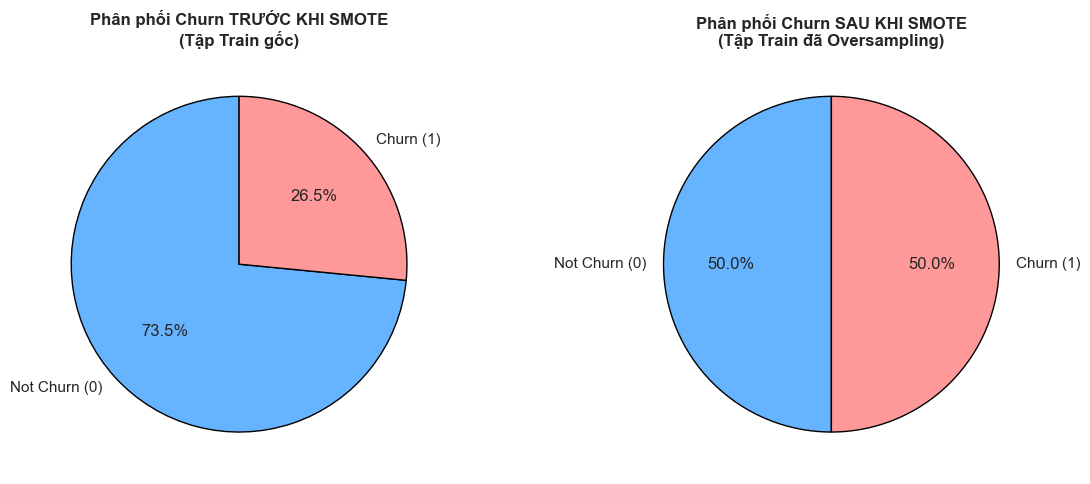


>>> Đã khởi tạo xong 2 mô hình Logistic Regression để so sánh.


In [40]:


# Giả định dữ liệu đầu vào từ bước trước là: X_train, y_train, X_test, y_test
# (X_train và X_test đã được làm sạch, mã hóa và scale)

# =====================================================================
# 4.3. XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU (SMOTE)
# =====================================================================

print("--- Thống kê y_train TRƯỚC KHI dùng SMOTE ---")
print(y_train.value_counts())

# 1. Khởi tạo và Fit SMOTE (CHỈ TRÊN TẬP TRAIN)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- Thống kê y_train_smote SAU KHI dùng SMOTE ---")
print(y_train_smote.value_counts())
print("\n=> Tỷ lệ nhãn 0 và 1 đã cân bằng hoàn toàn!")

# =====================================================================
# TRỰC QUAN HÓA KẾT QUẢ TRƯỚC VÀ SAU SMOTE
# =====================================================================

# Lấy dữ liệu đếm
counts_before = y_train.value_counts()
counts_after = y_train_smote.value_counts()
labels = ['Not Churn (0)', 'Churn (1)']
colors = ['#66b3ff', '#ff9999'] # Xanh cho Không rời mạng, Đỏ nhạt cho Rời mạng

# Tạo figure với 1 hàng, 2 cột
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: TRƯỚC KHI SMOTE
axes[0].pie(counts_before, labels=labels, autopct='%1.1f%%', startangle=90, 
            colors=colors, wedgeprops={'edgecolor': 'black'})
axes[0].set_title('Phân phối Churn TRƯỚC KHI SMOTE\n(Tập Train gốc)', fontweight='bold')

# Biểu đồ 2: SAU KHI SMOTE
axes[1].pie(counts_after, labels=labels, autopct='%1.1f%%', startangle=90, 
            colors=colors, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Phân phối Churn SAU KHI SMOTE\n(Tập Train đã Oversampling)', fontweight='bold')

plt.tight_layout()
plt.show()

# =====================================================================
# 4.4. KHỞI TẠO THUẬT TOÁN ĐỂ HUẤN LUYỆN
# =====================================================================

# Cách 1: Logistic Regression cơ bản 
# Sẽ được fit trên tập X_train_smote, y_train_smote (Dữ liệu đã tự cân bằng)
model_1_smote = LogisticRegression(random_state=42, max_iter=1000)

# Cách 2: Logistic Regression với class_weight='balanced'
# Sẽ được fit trên tập X_train, y_train (Dữ liệu gốc chưa SMOTE). 
# Thuật toán sẽ tự động phạt nặng hơn đối với các lỗi dự đoán sai nhóm thiểu số.
model_2_classweight = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

print("\n>>> Đã khởi tạo xong 2 mô hình Logistic Regression để so sánh.")

--- BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH TRÊN TẬP TEST ---
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.779      0.575   0.636     0.604    0.829
      Random Forest     0.787      0.601   0.588     0.595    0.821
            XGBoost     0.770      0.567   0.567     0.567    0.820


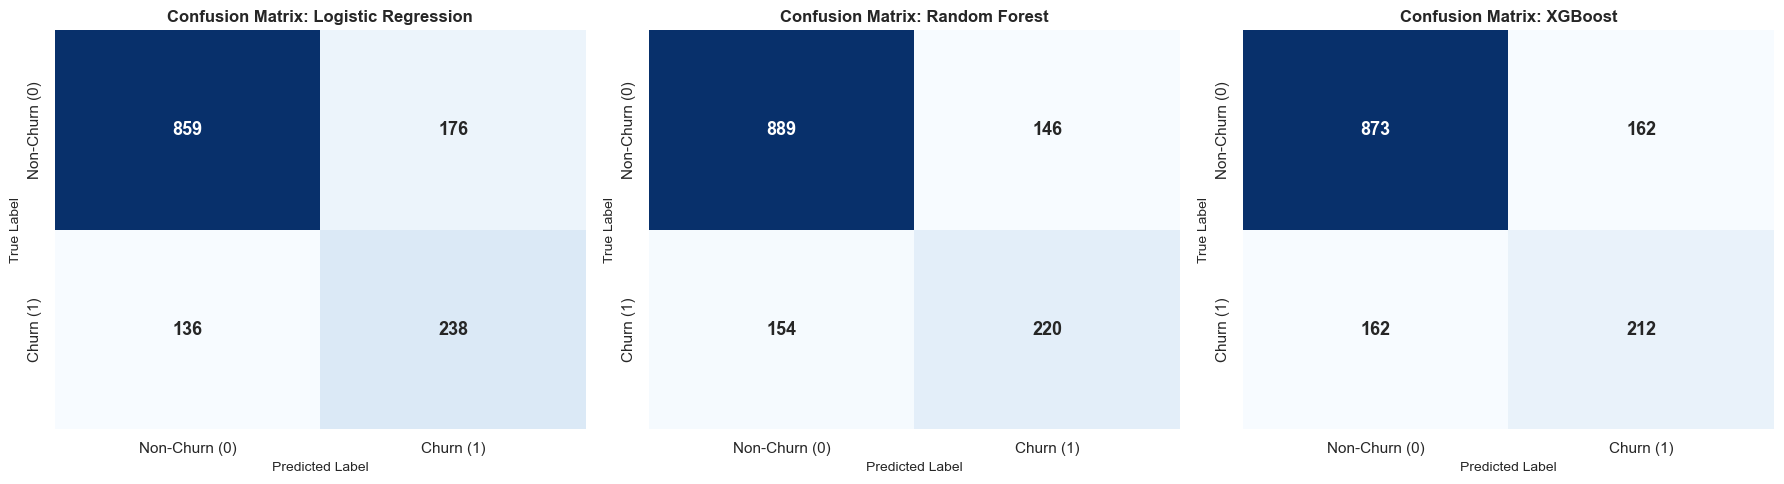

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

# 1. KHỞI TẠO MÔ HÌNH
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
}

# 2. HUẤN LUYỆN, DỰ ĐOÁN VÀ TÍNH CHỈ SỐ ĐÁNH GIÁ
results = []

for name, model in models.items():
    # Huấn luyện CHỈ trên tập Train đã SMOTE
    model.fit(X_train_smote, y_train_smote)

    # Dự đoán CHỈ trên tập Test gốc đã tiền xử lý (không chạm SMOTE)
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    # Tính toán các chỉ số đo lường
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)  # Ưu tiên cho nhãn Churn (1)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Lưu kết quả
    results.append(
        {
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1-Score": round(f1, 4),
            "ROC-AUC": round(auc, 4),
        }
    )

# =====================================================================
# 3. TỔNG HỢP VÀ IN BẢNG KẾT QUẢ
model_comparison_df = pd.DataFrame(results)

print("--- BẢNG SO SÁNH HIỆU NĂNG MÔ HÌNH TRÊN TẬP TEST ---")
print(model_comparison_df.to_string(index=False))

# =====================================================================
# 4. TRỰC QUAN HÓA MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        annot_kws={"size": 13, "weight": "bold"},
    )

    ax.set_title(f"Confusion Matrix: {name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    ax.set_xticklabels(["Non-Churn (0)", "Churn (1)"])
    ax.set_yticklabels(["Non-Churn (0)", "Churn (1)"])

plt.tight_layout()
plt.show()